<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/NLP_with_Deep_Learning_On_Fake_Job_Model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nltk
import os
import re
import string

nltk.download('punkt')
nltk.download('punkt_path')
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading punkt_path: Package 'punkt_path' not found
[nltk_data]     in index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df = pd.read_csv('/content/fake_job_postings.csv.zip')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df['text'] = (
    df['title'].fillna(' ')+" "+
    df['description'].fillna(' ')+" "+
    df['requirements'].fillna(' ')
)

df = df[['text','fraudulent']]

In [ ]:
df.head()

,text,fraudulent
0,"Marketing Intern Food52, a fast-growing, James...",0
1,Customer Service - Cloud Video Production Orga...,0
2,Commissioning Machinery Assistant (CMA) Our cl...,0
3,Account Executive - Washington DC THE COMPANY:...,0
4,Bill Review Manager JOB TITLE: Itemization Rev...,0


In [ ]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


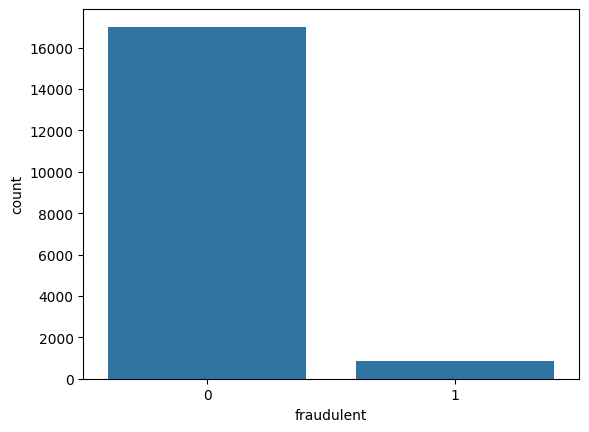

In [ ]:
sns.countplot(x=df['fraudulent'])
plt.show()


In [ ]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+",'',text)
  text = re.sub(r'<.*?>','',text)
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  return text

df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df.head()

,text,fraudulent,clean_text
0,"Marketing Intern Food52, a fast-growing, James...",0,marketing intern food a fastgrowing james bear...
1,Customer Service - Cloud Video Production Orga...,0,customer service cloud video production organ...
2,Commissioning Machinery Assistant (CMA) Our cl...,0,commissioning machinery assistant cma our clie...
3,Account Executive - Washington DC THE COMPANY:...,0,account executive washington dc the company e...
4,Bill Review Manager JOB TITLE: Itemization Rev...,0,bill review manager job title itemization revi...


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [ ]:
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x:[w for w in x if w not in stop_words])

In [ ]:
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x:[lemmatizer.lemmatize(w) for w in x])

df['final_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [ ]:
df.head()

,text,fraudulent,clean_text,tokens,final_text
0,"Marketing Intern Food52, a fast-growing, James...",0,marketing intern food a fastgrowing james bear...,"[marketing, intern, food, fastgrowing, james, ...",marketing intern food fastgrowing james beard ...
1,Customer Service - Cloud Video Production Orga...,0,customer service cloud video production organ...,"[customer, service, cloud, video, production, ...",customer service cloud video production organi...
2,Commissioning Machinery Assistant (CMA) Our cl...,0,commissioning machinery assistant cma our clie...,"[commissioning, machinery, assistant, cma, cli...",commissioning machinery assistant cma client l...
3,Account Executive - Washington DC THE COMPANY:...,0,account executive washington dc the company e...,"[account, executive, washington, dc, company, ...",account executive washington dc company esri e...
4,Bill Review Manager JOB TITLE: Itemization Rev...,0,bill review manager job title itemization revi...,"[bill, review, manager, job, title, itemizatio...",bill review manager job title itemization revi...


In [ ]:
from collections import Counter
all_words = " ".join(df['final_text']).split()
word_freq = Counter(all_words).most_common(20)

freq_df = pd.DataFrame(word_freq,columns=['word','frequency'])
freq_df.head()

,word,frequency
0,experience,30987
1,team,25512
2,work,24807
3,customer,20595
4,service,17710


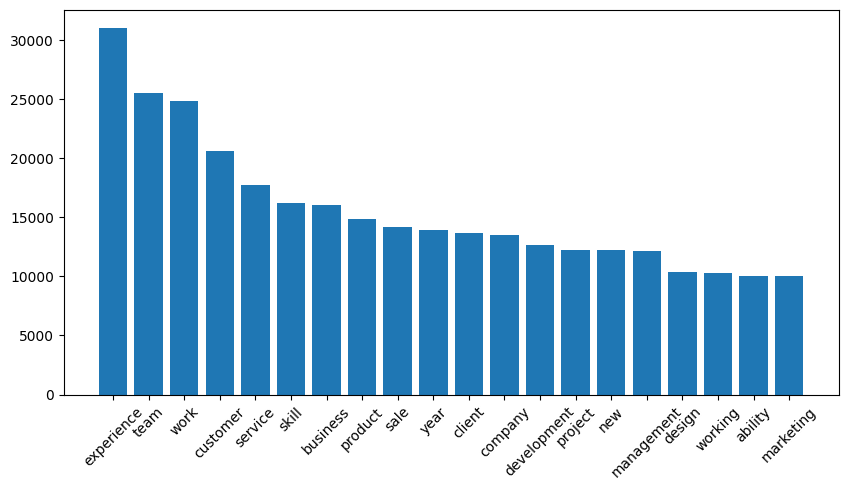

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(freq_df['word'], freq_df['frequency'])
plt.xticks(rotation=45)
plt.show()

In [ ]:
from collections import Counter

print("Total words:", len(all_words))
print("Unique words:", len(set(all_words)))
print("Sample words:", all_words[:20])
print("Top frequencies:", Counter(all_words).most_common(10))

Total words: 2875161
Unique words: 138072
Sample words: ['marketing', 'intern', 'food', 'fastgrowing', 'james', 'beard', 'awardwinning', 'online', 'food', 'community', 'crowdsourced', 'curated', 'recipe', 'hub', 'currently', 'interviewing', 'full', 'parttime', 'unpaid', 'intern']
Top frequencies: [('experience', 30987), ('team', 25512), ('work', 24807), ('customer', 20595), ('service', 17710), ('skill', 16221), ('business', 16023), ('product', 14829), ('sale', 14179), ('year', 13872)]


Unique clean words: 137606


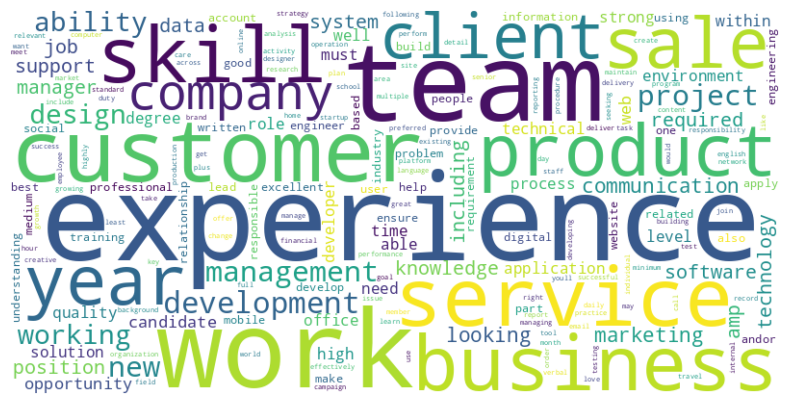

In [ ]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

# Clean properly
clean_words = [
    str(w).lower().strip()
    for w in all_words
    if str(w).isalpha() and len(str(w)) > 2
]

freq = Counter(clean_words)

print("Unique clean words:", len(freq))

if len(freq) > 0:
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
else:
    print("No drawable words found.")




In [ ]:
fig = px.scatter_3d(
    freq_df,
    x='word',
    y='frequency',
    z='frequency'
)

fig.show()

In [ ]:
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['final_text'])

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['final_text'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df['fraudulent'],
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3395
           1       1.00      0.33      0.49       181

    accuracy                           0.97      3576
   macro avg       0.98      0.66      0.74      3576
weighted avg       0.97      0.97      0.96      3576



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       1.00      0.54      0.70       181

    accuracy                           0.98      3576
   macro avg       0.99      0.77      0.85      3576
weighted avg       0.98      0.98      0.97      3576



In [ ]:
!pip install gensim
from gensim.models import Word2Vec

tokenized = df['tokens'].tolist()

w2v = Word2Vec(tokenized, vector_size=100, window=5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.6 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer

model_emb = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model_emb.encode(df['final_text'][:1000])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
emb_3d = pca.fit_transform(embeddings)

fig = px.scatter_3d(
    x=emb_3d[:,0],
    y=emb_3d[:,1],
    z=emb_3d[:,2]
)
fig.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['final_text'])

seq = tokenizer.texts_to_sequences(df['final_text'])
X_pad = pad_sequences(seq, maxlen=200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_dl = Sequential([
    Embedding(5000,128),
    LSTM(128),
    Dense(1,activation='sigmoid')
])

model_dl.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_dl.fit(X_pad, df['fraudulent'], epochs=3)

Epoch 1/3
559/559 ━━━━━━━━━━━━━━━━━━━━ 195s 341ms/step - accuracy: 0.9485 - loss: 0.2152
Epoch 2/3
559/559 ━━━━━━━━━━━━━━━━━━━━ 200s 337ms/step - accuracy: 0.9740 - loss: 0.0878
Epoch 3/3
559/559 ━━━━━━━━━━━━━━━━━━━━ 186s 333ms/step - accuracy: 0.9857 - loss: 0.0465


In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(5000,128),
    Conv1D(128,5,activation='relu'),
    GlobalMaxPooling1D(),
    Dense(1,activation='sigmoid')
])

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier("Great opportunity job")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998447895050049}]

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression())
])

pipeline.fit(df['final_text'], df['fraudulent'])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression())])

In [ ]:
import joblib
joblib.dump(pipeline, "fake_job_model.pkl")

['fake_job_model.pkl']

In [ ]:
model = joblib.load("fake_job_model.pkl")

def predict_job(text):
    return model.predict([text])

predict_job("Earn 5000$ weekly without experience")

array([0])